# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (GraphCast vs FCN vs ERA5 reanalysis)
4. **850 hPa Moisture** visualization (GraphCast)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [ ]:
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

import earth2studio.run as run
from earth2studio.models.px import FCN, SFNO, GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/earth2studio-project")
os.chdir(PROJECT_DIR)

print(f"Device: {DEVICE}")

## 2m Air Temperature Forecast

In [22]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
io = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-08"], 10, model, data, io)
print(io.root.tree())

2026-04-08 22:43:25.637 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-08 22:43:25.638 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-04-08 22:43:26.384 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 337303134-947326
2026-04-08 22:43:26.387 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 413181533-966042
2026-04-08 22:43:26.388 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 458275515-977912
2026-04-08 22:43:26.390 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 400526668-837990
2026-04-08 22:43:26.392 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 329645190-898530
2026-04-08 22:43:26.393 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 24.39it/s]


2026-04-08 22:43:27.532 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-08 22:43:27.588 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference: 100%|██████████| 11/11 [00:10<00:00,  1.04it/s]

2026-04-08 22:43:38.138 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (720,) float64
├── lead_time (11,) timedelta64
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32
├── z250 (1, 11, 720, 1440) float32
├── z50 (1, 11, 720, 1440) float32
├── z500 (1, 11, 720, 1440) float32
└── z850 (1, 11, 720, 1440) float32

<Figure size 640x480 with 0 Axes>

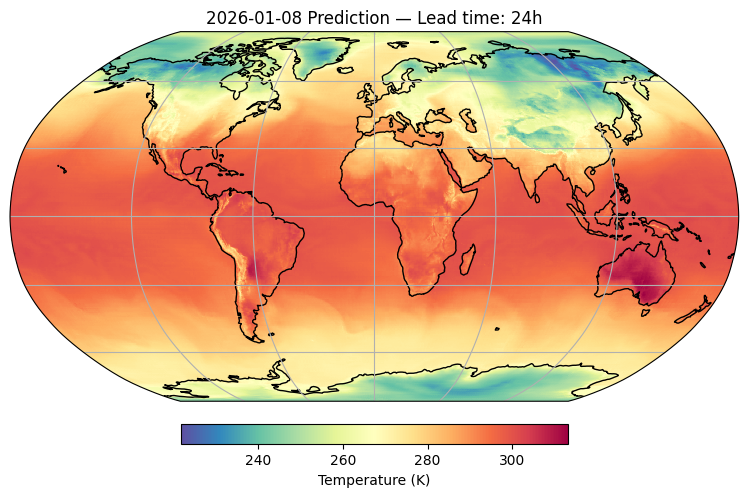

In [24]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [ ]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
io = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-01"], 10, sfno_model, data, io)
print(io.root.tree())

In [ ]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

In [ ]:
# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=8, extent=[220, 340, 20, 70])

In [ ]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from GraphCast, FCN, and ERA5 reanalysis for Hurricane Florence (September 2018).

In [9]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [10]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — GraphCast Operational

In [11]:
graphcast_model = GraphCastOperational.load_model(GraphCastOperational.load_default_package())
wb2_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()

graphcast_tracks = run_tc_inference(
    graphcast_model, wb2_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "graphcast_operational_paths.pt",
)

Fetching WB2 data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-08 18:55:37.467 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t200 at 2018-09-12T18:00:00
2026-04-08 18:55:37.468 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: w850 at 2018-09-12T18:00:00
2026-04-08 18:55:37.469 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t150 at 2018-09-12T18:00:00
2026-04-08 18:55:37.470 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t50 at 2018-09-12T18:00:00
2026-04-08 18:55:37.471 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z500 at 2018-09-12T18:00:00
2026-04-08 18:55:37.473 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t300 at 2018-09-12T18:00:00
2026-04-08 18:55:37.474 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t250 at 2018-09-12T18:00:00


Fetching WB2 data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-08 18:55:41.958 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t50 at 2018-09-13T00:00:00
2026-04-08 18:55:41.959 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: w700 at 2018-09-13T00:00:00
2026-04-08 18:55:41.961 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t100 at 2018-09-13T00:00:00
2026-04-08 18:55:41.961 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t150 at 2018-09-13T00:00:00
2026-04-08 18:55:41.962 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: z400 at 2018-09-13T00:00:00
2026-04-08 18:55:41.963 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: q700 at 2018-09-13T00:00:00
2026-04-08 18:55:41.964 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: t250 at 2018-09-13T00:00:00


 96%|█████████▌| 25/26 [01:45<00:04,  4.22s/it]

Saved: /home/jovyan/earth2studio-project/florence_outputs/graphcast_operational_paths.pt


### 3b — ERA5 Reanalysis (ground truth)

In [12]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

  0%|          | 0/26 [00:00<?, ?it/s]
                                      5 [00:00<?, ?it/s]
  0%|          | 0/26 [00:00<?, ?it/s]                  
                                      5 [00:00<?, ?it/s]
  0%|          | 0/26 [00:00<?, ?it/s]                  
                                      5 [00:00<?, ?it/s]
  0%|          | 0/26 [00:00<?, ?it/s]                  
                                      5 [00:00<?, ?it/s]
  0%|          | 0/26 [00:00<?, ?it/s]                  
                                      5 [00:00<?, ?it/s]
Fetching WB2 data: 100%|██████████| 5/5 [00:00<00:00, 73.46it/s]


2026-04-08 18:58:24.398 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T00:00:00
2026-04-08 18:58:24.401 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T00:00:00
2026-04-08 18:58:24.403 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T00:00:00
2026-04-08 18:58:24.405 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T00:00:00
2026-04-08 18:58:24.407 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T00:00:00


  4%|▍         | 1/26 [00:00<00:05,  4.40it/s]
                                              <?, ?it/s]
  4%|▍         | 1/26 [00:00<00:05,  4.40it/s]          
                                              <?, ?it/s]
  4%|▍         | 1/26 [00:00<00:05,  4.40it/s]          
                                              <?, ?it/s]
  4%|▍         | 1/26 [00:00<00:05,  4.40it/s]          
                                              <?, ?it/s]
  4%|▍         | 1/26 [00:00<00:05,  4.40it/s]          
                                              <?, ?it/s]
Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-08 18:58:24.626 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-13T06:00:00
2026-04-08 18:58:24.628 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-13T06:00:00
2026-04-08 18:58:24.630 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-13T06:00:00
2026-04-08 18:58:24.632 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-13T06:00:00
2026-04-08 18:58:24.635 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-13T06:00:00



  8%|▊         | 2/26 [00:01<00:20,  1.15it/s]
                                              <?, ?it/s]
  8%|▊         | 2/26 [00:01<00:20,  1.15it/s]          
                                              <?, ?it/s]
  8%|▊         | 2/26 [00:01<00:20,  1.15it/s]          
                                              <?, ?it/s]
  8%|▊         | 2/26 [00:01<00:20,  1.15it/s]          
                                              <?, ?it/s]
  8%|▊         | 2/26 [00:01<00:20,  1.15it/s]          
                                              <?, ?it/s]
Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-04-08 18:58:50.009 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T00:00:00
2026-04-08 18:58:50.011 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T00:00:00
2026-04-08 18:58:50.013 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-19T00:00:00
2026-04-08 18:58:50.015 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T00:00:00
2026-04-08 18:58:50.017 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T00:00:00



 96%|█████████▌| 25/26 [00:26<00:01,  1.08s/it]
                                               ?, ?it/s]
 96%|█████████▌| 25/26 [00:26<00:01,  1.08s/it]         
                                               ?, ?it/s]
 96%|█████████▌| 25/26 [00:26<00:01,  1.08s/it]         
                                               ?, ?it/s]
 96%|█████████▌| 25/26 [00:26<00:01,  1.08s/it]         
                                               ?, ?it/s]
 96%|█████████▌| 25/26 [00:26<00:01,  1.08s/it]         
                                               ?, ?it/s]
Fetching WB2 data:   0%|          | 0/5 [00:00<?, ?it/s]

2026-04-08 18:58:51.118 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v10m at 2018-09-19T06:00:00
2026-04-08 18:58:51.120 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u10m at 2018-09-19T06:00:00
2026-04-08 18:58:51.122 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: msl at 2018-09-19T06:00:00
2026-04-08 18:58:51.124 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: v850 at 2018-09-19T06:00:00
2026-04-08 18:58:51.126 | DEBUG    | earth2studio.data.wb2:fetch_array:241 - Fetching WB2 zarr array for variable: u850 at 2018-09-19T06:00:00



100%|██████████| 26/26 [00:27<00:00,  1.07s/it]

Saved ERA5 tracks


### 3c — FCN

In [15]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

2026-04-08 19:03:10.562 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: Z in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_129_z.ll025sc.2018091300_2018091323.nc


Fetching NCAR ERA5 data:   0%|          | 0/13 [00:00<?, ?it/s]

2026-04-08 19:03:10.595 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: MSL in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_151_msl.ll025sc.2018090100_2018093023.nc
2026-04-08 19:03:10.838 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: 100U in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.228_246_100u.ll025sc.2018090100_2018093023.nc
2026-04-08 19:03:10.840 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: V in file s3://nsf-ncar-era5/e5.oper.an.pl/201809/e5.oper.an.pl.128_132_v.ll025uv.2018091300_2018091323.nc
2026-04-08 19:03:10.842 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: 10U in file s3://nsf-ncar-era5/e5.oper.an.sfc/201809/e5.oper.an.sfc.128_165_10u.ll025sc.2018090100_2018093023.nc
2026-04-08 19:03:10.843 | DEBUG    | earth2studio.data.ncar:fetch_array:398 - Fetching NCAR ERA5 variable: SP in file s3://n

 96%|█████████▌| 25/26 [00:04<00:00,  5.39it/s]

Saved: /home/jovyan/earth2studio-project/florence_outputs/fcn_paths.pt


### 3d — Plot Track Comparison

In [16]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

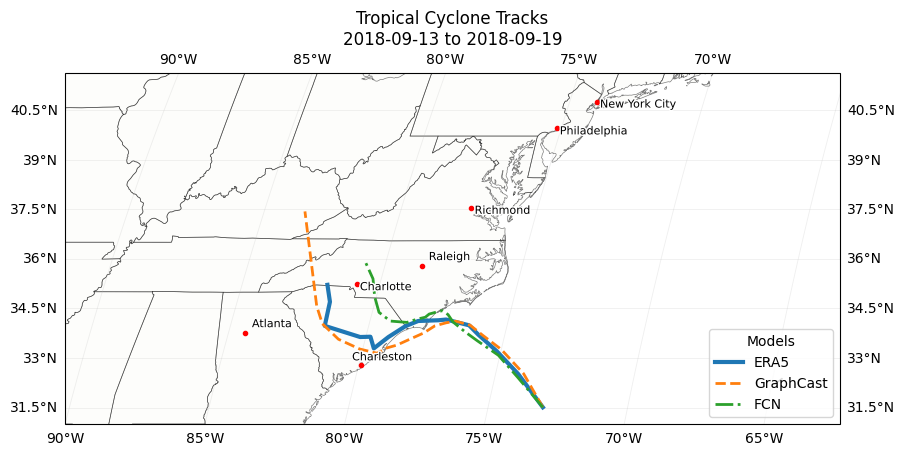

In [17]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
graphcast_load = torch.load(FLORENCE_DIR / "graphcast_operational_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte", 35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh", 35.7796, -78.6382,  0.18,  0.18),
    ("Charleston", 32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta", 33.7490, -84.3880,  0.18,  0.18),
    ("Richmond", 37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5", "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "GraphCast", "tracks": graphcast_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN", "tracks": fcn_load, "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)

## 850 hPa Moisture Visualization (GraphCast)

In [3]:
model = GraphCastOperational.load_model(GraphCastOperational.load_default_package())
data = GFS()

tcwv_path = PROJECT_DIR / "tcwv_outputs/graphcast_tcwv_forecast.zarr"
tcwv_path.parent.mkdir(parents=True, exist_ok=True)
io = ZarrBackend(str(tcwv_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2024-09-26"], 16, model, data, io)
print(io.root.tree())

2026-04-08 19:52:41.777 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-08 19:52:41.777 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda


Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-08 19:52:42.511 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 415460040-514301
2026-04-08 19:52:42.514 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 300208520-871034
2026-04-08 19:52:42.516 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 197793871-586213
2026-04-08 19:52:42.517 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 334511690-915647
2026-04-08 19:52:42.519 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240925/18/atmos/gfs.t18z.pgrb2.0p25.f000 0-1009684
2026-04-08 19:52:42.520 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib fi

Fetching GFS data:   0%|          | 0/82 [00:00<?, ?it/s]

2026-04-08 19:52:45.855 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 287761771-927695
2026-04-08 19:52:45.857 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 284277575-1228563
2026-04-08 19:52:45.859 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 265730425-942426
2026-04-08 19:52:45.861 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 262176482-1298175
2026-04-08 19:52:45.863 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240926/00/atmos/gfs.t00z.pgrb2.0p25.f000 243853289-587015
2026-04-08 19:52:45.865 | DEBUG    | earth2studio.data.gfs:fetch_array:382 - Fetching GF

Fetching GFS data: 100%|██████████| 82/82 [00:02<00:00, 34.68it/s]


2026-04-08 19:52:48.742 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-04-08 19:52:48.871 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Running inference:   6%|▌         | 1/17 [00:05<01:26,  5.42s/it]WARNING:absl:Skipping gradient checkpointing for sequence length of 1

Running inference: 100%|██████████| 17/17 [01:52<00:00,  6.64s/it]

2026-04-08 19:54:41.830 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


/
├── lat (721,) float64
├── lead_time (17,) timedelta64
├── lon (1440,) float64
├── msl (1, 17, 721, 1440) float32
├── q100 (1, 17, 721, 1440) float32
├── q1000 (1, 17, 721, 1440) float32
├── q150 (1, 17, 721, 1440) float32
├── q200 (1, 17, 721, 1440) float32
├── q250 (1, 17, 721, 1440) float32
├── q300 (1, 17, 721, 1440) float32
├── q400 (1, 17, 721, 1440) float32
├── q50 (1, 17, 721, 1440) float32
├── q500 (1, 17, 721, 1440) float32
├── q600 (1, 17, 721, 1440) float32
├── q700 (1, 17, 721, 1440) float32
├── q850 (1, 17, 721, 1440) float32
├── q925 (1, 17, 721, 1440) float32
├── t100 (1, 17, 721, 1440) float32
├── t1000 (1, 17, 721, 1440) float32
├── t150 (1, 17, 721, 1440) float32
├── t200 (1, 17, 721, 1440) float32
├── t250 (1, 17, 721, 1440) float32
├── t2m (1, 17, 721, 1440) float32
├── t300 (1, 17, 721, 1440) float32
├── t400 (1, 17, 721, 1440) float32
├── t50 (1, 17, 721, 1440) float32
├── t500 (1, 17, 721, 1440) float32
├── t600 (1, 17, 721, 1440) float32
├── t700 (1, 17, 721, 1440) float32
├── t850 (1, 17, 721, 1440) float32
├── t925 (1, 17, 721, 1440) float32
├── time (1,) datetime64
├── tp06 (1, 17, 721, 1440) float32
├── u100 (1, 17, 721, 1440) float32
├── u1000 (1, 17, 721, 1440) float32
├── u10m (1, 17, 721, 1440) float32
├── u150 (1, 17, 721, 1440) float32
├── u200 (1, 17, 721, 1440) float32
├── u250 (1, 17, 721, 1440) float32
├── u300 (1, 17, 721, 1440) float32
├── u400 (1, 17, 721, 1440) float32
├── u50 (1, 17, 721, 1440) float32
├── u500 (1, 17, 721, 1440) float32
├── u600 (1, 17, 721, 1440) float32
├── u700 (1, 17, 721, 1440) float32
├── u850 (1, 17, 721, 1440) float32
├── u925 (1, 17, 721, 1440) float32
├── v100 (1, 17, 721, 1440) float32
├── v1000 (1, 17, 721, 1440) float32
├── v10m (1, 17, 721, 1440) float32
├── v150 (1, 17, 721, 1440) float32
├── v200 (1, 17, 721, 1440) float32
├── v250 (1, 17, 721, 1440) float32
├── v300 (1, 17, 721, 1440) float32
├── v400 (1, 17, 721, 1440) float32
├── v50 (1, 17, 721, 1440) float32
├── v500 (1, 17, 721, 1440) float32
├── v600 (1, 17, 721, 1440) float32
├── v700 (1, 17, 721, 1440) float32
├── v850 (1, 17, 721, 1440) float32
├── v925 (1, 17, 721, 1440) float32
├── w100 (1, 17, 721, 1440) float32
├── w1000 (1, 17, 721, 1440) float32
├── w150 (1, 17, 721, 1440) float32
├── w200 (1, 17, 721, 1440) float32
├── w250 (1, 17, 721, 1440) float32
├── w300 (1, 17, 721, 1440) float32
├── w400 (1, 17, 721, 1440) float32
├── w50 (1, 17, 721, 1440) float32
├── w500 (1, 17, 721, 1440) float32
├── w600 (1, 17, 721, 1440) float32
├── w700 (1, 17, 721, 1440) float32
├── w850 (1, 17, 721, 1440) float32
├── w925 (1, 17, 721, 1440) float32
├── z100 (1, 17, 721, 1440) float32
├── z1000 (1, 17, 721, 1440) float32
├── z150 (1, 17, 721, 1440) float32
├── z200 (1, 17, 721, 1440) float32
├── z250 (1, 17, 721, 1440) float32
├── z300 (1, 17, 721, 1440) float32
├── z400 (1, 17, 721, 1440) float32
├── z50 (1, 17, 721, 1440) float32
├── z500 (1, 17, 721, 1440) float32
├── z600 (1, 17, 721, 1440) float32
├── z700 (1, 17, 721, 1440) float32
├── z850 (1, 17, 721, 1440) float32
└── z925 (1, 17, 721, 1440) float32

In [18]:
def plot_moisture(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    q850 = ds["q850"][0, step] * 1000  # convert kg/kg to g/kg
    projection = ccrs.Robinson()
    levels = np.arange(0, 18, 1)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], q850, levels,
        transform=ccrs.PlateCarree(), cmap="GnBu", extend="neither",
    )
    plt.colorbar(im, ax=ax, orientation="horizontal", shrink=0.55, pad=0.05,
                 label="Specific Humidity at 850 hPa (g/kg)", aspect = 30)
    ax.set_title(f"GraphCast — 2024-09-26 — 850 hPa Moisture — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

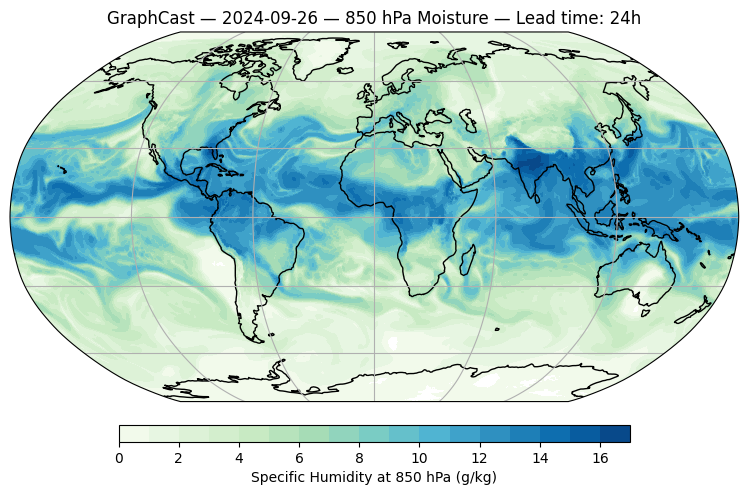

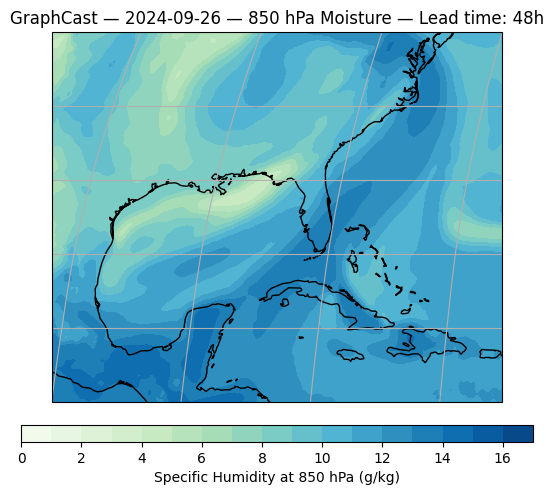

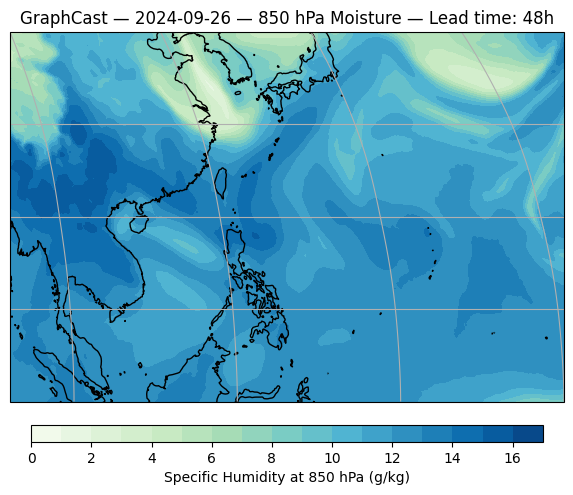

In [19]:
# Global view
plot_moisture(tcwv_path, step=4)

# Gulf Coast
plot_moisture(tcwv_path, step=8, extent=[-100, -70, 15, 40])

# Western Pacific tropical moisture
plot_moisture(tcwv_path, step=8, extent=[100, 160, 0, 40])